# **NLP Project 2026: Web Novel and Light Novel labels predictions**
##### **Authors: *Arno LESAGE (no. 22202985), Minh Quan Hoang (no. 22509118)***

greta.damo@inria.fr

## 1- Research Questions
**Requirements (120 words):** In the world of bookworms, being able to tell the different genres of a Light Novel (LN) or a Web Novel (WN) based on its description is very common. Unfortunately, this apparent simplicity represent a quite difficult task for computers. Using the not so known [*Web/Light Novel Dataset*](https://www.kaggle.com/datasets/premshinde/weblight-novel-dataset), our goal is to predict, from the description of a book, the associated genre(s). We emits the hypothesis (already used for movies classification) that a description unveils a particular semantic depending on the genres they are associated with. As instance, a LN with the `Horror` tag is more likely to have a *gore* description than a `Romance/School Life` LN. Additionally, we also emit the hypothesis of high correlation between genres (`Adventure` implies `Fantasy` or `Drama/Romance`).  

**Required Reflection:** 

**[Q1] Why is your research question non trivial?** Multiple difficulties arise with this research question, but the two main difficulties are the high number of genres (35 in our dataset), but also their correlation together, which would render discrimination attempt difficult (Note: maybe it correlation could be turn into strength).

**[Q2] What linguistic phenomenon does it involve?** The linguistics phenomenon involved we want to capture here is the underlying semantics of the different genres. We expect more joyful "words" and sentences structures for genres like `Romance/Comedy`, more tendentious for `Adult/Ecchi/Harem/Gender Bender`, more youthful for `Shoujo/Shounen/Adventure` and so on.

**[Q3] What would falsify your hypothesis?** A possible justification for our hypothesis being falsified could be that the translation of the description from the original language (Chinese, Korean, Japanese, Vietnamese, ...) to english removed some details and damaged the underlying semantics. 

## 2.1 - Dataset Selection
The dataset chosen for this project is the [*Web/Light Novel Dataset*](https://www.kaggle.com/datasets/premshinde/weblight-novel-dataset) (original-wn-dataset.csv). 

- **Source:** Kaggle, Web/Light Novel Dataset, Prem Shinde, 2024
- **Domain:** Literature, Web/Light Novels, Asian Literature
- **Label Distribution:** Multilabel, Heterogeneous (some labels have 106, others 7523), "exponential" unbalanced distributions of labels.
- **Potential biases:** Correlation between books origins and labels, correlation between labels, traduction failures of Chinese, Japanese, Korean, Vietnamese, ... to English.
- **Ethical Consideration:** Methodology for extraction is unknown. Apart from this, this dataset does not exhibit particular ethicals considerations.
- **Size:** 11770 labeled documents, 74.87MB.
- **Main Content:** Title, Description [Classifiers], Source (URL), Genres [Predicted variable], Tags (Sub genres), related series, authors, artists, original language...

Despite relatively poor documentation, this dataset was chosen as it is more complete (more instances) in comparison with other available alternative, possess a bigger variety of genres and tags, but also is easier to navigate. Alternative could have been:
- [RanobeDB](https://ranobedb.org/database-dumps): SQL Database containing series and books for manga, LN and WN. (difficult to navigate),
- [MyAnimeList Dataset](https://www.kaggle.com/datasets/dbdmobile/myanimelist-dataset): Very complete and good documentation, but has less variety and may not contains LN and WN independent productions.
- [Anime Title Dataset](https://huggingface.co/datasets/realoperator42/anime-titles-dataset): Complete, but has very low number of instances (<1000) and Anime Only.

More informations on the shape of the dataset in the part **(2.1 - In Depth)**

### **Libraries**

In [2]:
# Default package
import re
from collections import Counter
from itertools import chain
import time
import pickle as pkl

# Visualisation
%matplotlib widget
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# Base ML
import numpy as np
import pandas as pd
import csv

# Preprocessing
from nltk.corpus import stopwords
stop_words = set(stopwords.words("english"))
import spacy
nlp = spacy.load("en_core_web_sm")

# Vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Multilabel ML
from skmultilearn.model_selection import iterative_train_test_split
from sklearn.preprocessing import MultiLabelBinarizer

### **Import the dataset (original-wn)**

In [3]:
df = pd.read_csv("datasets/original-wn-dataset.csv")
df.describe(include="all")

,novel_id,url,title,associated_names,img_url,showtype,genres,tags,description,related_series,...,publishers,en_pubs,release_frequency,weekly_rank,monthly_rank,all_time_rank,monthly_rank_reading_list,all_time_rank_reading_list,total_reading_list_rank,chapters
count,11770.000000,11770,11770,11770,11770,11700,11770,11770,11766,11770,...,11770,11770,11769,11770,11770,11770,11770,11770,11770.000000,11770
unique,NaN,11770,11768,11619,10159,20,6014,11215,11676,1325,...,1213,69,3721,474,2600,8282,3091,6533,NaN,10488
top,NaN,after-the-breakup-i-went-viral-in-the-entertai...,The Imperial Concubine Just Wants To Be a Salt...,[],https://www.novelupdates.com/img/noimagefound.jpg,Web Novel (CN),['Fantasy' 'Romance'],[],N/A\n,"{'related_series': array([], dtype=object), 't...",...,['jjwxc'],[],Every 2000 Day(s),#2000,#2000,#14613,#15649,#11754,NaN,"{'chapters': array([], dtype=object), 'total': 0}"
freq,NaN,1,2,97,1607,5592,230,155,66,10398,...,2216,10454,118,6097,5699,13,418,13,NaN,1283
mean,34047.713084,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1664.066950,NaN
std,19129.992708,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2436.728268,NaN
min,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.000000,NaN
25%,18403.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,300.000000,NaN
50%,35094.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,740.000000,NaN
75%,50761.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1981.000000,NaN


For our NLP classification task, we are interested on the following columns `novel_id`, `title`, `genres`, `tags` and `description`.

In [4]:
df_filtered = df.loc[:, ["novel_id", "title", "genres", "tags", "description"]]
df_filtered.head()

,novel_id,title,genres,tags,description
0,64494,"After the Breakup, I Went Viral in the Enterta...",['Drama' 'Fantasy' 'Romance' 'Supernatural'],['Amnesia' 'Beautiful Female Lead' 'Clever Pro...,"Luo Ning was a cannon fodder, a female support..."
1,43962,Mahou Sekai no Monogatari,['Fantasy' 'Romance' 'Shoujo'],['Adventurers' 'Elemental Magic' 'Familiars' '...,A world where magic exists.\nThis is the story...
2,25506,I am a Good Man,['Action' 'Adventure' 'Fantasy' 'Historical' '...,['Beautiful Female Lead' 'Businessmen' 'Childc...,"To sum up in a sentence, transmigrating to dif..."
3,50373,Scum Girl Practice Manual,['Romance' 'School Life' 'Shoujo'],['Female Protagonist' 'Modern Day' 'Short Stor...,"My goal is, to be a scum woman.\n"
4,48291,Unable to Divorce After Signing the Marriage C...,['Psychological' 'Romance' 'Shounen Ai' 'Slice...,['Arranged Marriage' 'Calm Protagonist' 'Cold ...,Lin You He excelled in everything – his looks...


### **Preprocess Dataset Format**

Using the `.head()` command, we observe that the `genres` and `tags` columns are encoded into space separated list, which are not recognised in Python, so we will have to change the format to proper lists.

In [5]:
def colToList (x:str) -> list[str]:
    # Detect the separator
    x = re.sub(r"'[\n ].?'", ",",x)
    
    # Remove the indicator of the raw space separated list and split on coma
    xSplit = x.removeprefix("['").removesuffix("']").split(",")
    
    # Return the list where the text is capitalize (it is just prettier)
    return list(map(str.capitalize, xSplit))

# Apply the split
df_filtered.loc[:,"genres"] = df_filtered.loc[:,"genres"].apply(lambda x: colToList(x))
df_filtered.loc[:,"tags"] = df_filtered.loc[:,"tags"].apply(lambda x: colToList(x))
df_filtered.head()

,novel_id,title,genres,tags,description
0,64494,"After the Breakup, I Went Viral in the Enterta...","[Drama, Fantasy, Romance, Supernatural]","[Amnesia, Beautiful female lead, Clever protag...","Luo Ning was a cannon fodder, a female support..."
1,43962,Mahou Sekai no Monogatari,"[Fantasy, Romance, Shoujo]","[Adventurers, Elemental magic, Familiars, Fema...",A world where magic exists.\nThis is the story...
2,25506,I am a Good Man,"[Action, Adventure, Fantasy, Historical, Roman...","[Beautiful female lead, Businessmen, Childcare...","To sum up in a sentence, transmigrating to dif..."
3,50373,Scum Girl Practice Manual,"[Romance, School life, Shoujo]","[Female protagonist, Modern day, Short story, ...","My goal is, to be a scum woman.\n"
4,48291,Unable to Divorce After Signing the Marriage C...,"[Psychological, Romance, Shounen ai, Slice of ...","[Arranged marriage, Calm protagonist, Cold pro...",Lin You He excelled in everything – his looks...


## 2.1bis (and 3.1.) - in depth - Some stats on the dataset
Now that everything is correctly imported, we will observe some statistics on our dataset to understand it. First, we will try to understand what kind of language is used in our data.
##### **Description language** 
To achieve this goal, we will first take a look at the most frequent words in our dataset. We will build a function to compare with and without stopwords.

In [6]:
def plotDescriptionLanguage(df:pd.DataFrame, col="description", stopFiltered=True):
    descriptionList = list(map(str,df.loc[:,col].to_list()))
    descriptionString = " ".join(descriptionList)
    # Match all words and digits
    wordDescriptionList = re.findall(r"[\w\d-]+",descriptionString)

    # Remove the stopwords if asked
    wordDescriptionList = [i.capitalize() for i in wordDescriptionList if (i.lower() not in stop_words) or not stopFiltered]

    # Apply the counter
    wordDescriptionListCounter = Counter(wordDescriptionList)

    # Sort the counter
    wordDescriptionListCounterSorted = [[],[]]
    for word in sorted(wordDescriptionListCounter, key=lambda x:wordDescriptionListCounter[x], reverse=True):
        wordDescriptionListCounterSorted[0].append(word)
        wordDescriptionListCounterSorted[1].append(wordDescriptionListCounter[word])

    # Make a plot
    plt.close("all")
    sns.set_style("dark")
    sns.barplot(
        x=wordDescriptionListCounterSorted[1][:40],
        y=wordDescriptionListCounterSorted[0][:40],
        palette="BrBG"    
    )
    plt.title(f"Wordcount {'(stopwords filtered)' if stopFiltered else ''}")
    plt.xlabel("Wordcount")
    plt.ylabel("Words")

    plt.show()
    
    return wordDescriptionListCounterSorted
    

Now that we have the function, we can start without stopwords filtering:

C:\Users\arnol\AppData\Local\Temp\ipykernel_13788\1773452185.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


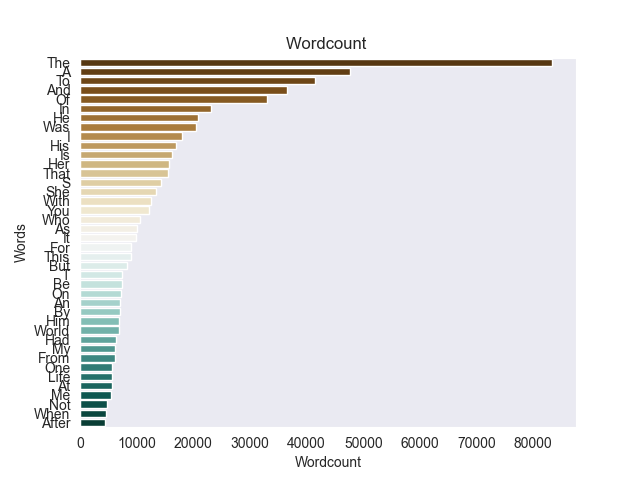

In [7]:
df_filteredWordCounter = plotDescriptionLanguage(df_filtered, stopFiltered=False)

Here, we quickly observe that, as expected, all of the most frequent words are stopwords (A, The, To, And, Of, ...). This is bad news. Indeed, these words in this context will not exhibits high semantic importance in the document, but could possess tremendous weights in our future embeddings. We will now do the same plot without stopwords (using `nltk` stopwords list for English).  

C:\Users\arnol\AppData\Local\Temp\ipykernel_13788\1773452185.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


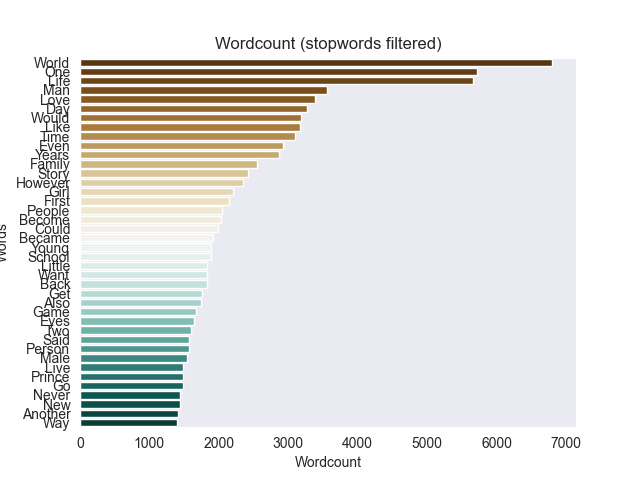

In [8]:
_ = plotDescriptionLanguage(df_filtered)

Here, we clearly observe the difference. Generic stopwords aside, we observe some interesting words like `World`, `Life`, `Prince`, `Story` and `Time`, which could possibly be tied to some genres like `Fantasy` or `Adventure` considering their popularity. Another predominant family emerges here with `School`, `Young`, `Family` and `Love` which are typical of the genres `School Life` and `Romance`. In the end, we really see some "specialised" topics compared to political, economical, scientific or newspapers texts that we are used to.

But now, what about the least used words and the frequency in global?

In [9]:
df_filteredWordDescription = pd.DataFrame(columns=["Word", "Frequency"])
df_filteredWordDescription["Word"] = pd.Series(df_filteredWordCounter[0])
df_filteredWordDescription["Frequency"] = pd.Series(df_filteredWordCounter[1])
df_filteredWordDescription

,Word,Frequency
0,The,83384
1,A,47692
2,To,41495
3,And,36481
4,Of,33092
...,...,...
41020,Strength-worshiping,1
41021,Adult-based,1
41022,Seryu,1
41023,Wisemen,1


Here, using the table, we observe that the nature of least used words could be categorised (broadly) in four categories: composed words (`Strength-worshiping`, `Adult-based`, `Good-nature`), names (`Tsuruki`, `Zhaoying`, `Ikaros`), specialised words (`Euthanasia`, `Canines`, `Serializing`) or non-English components (`Otouto`, `Giraffe`, `100g`, `1920`, `房事`).

Additionally, we observe that 22603 unique words (55.10%) appears less than 2 times and that even 16732 words (40.78%) appears only once. This observation will render necessary to filter rare words.

In the end, the proportion of words that could  be considered "frequent" (20 words or more) is of approximately 12.3%. Concerning "very frequent words" (100+ occurrences), only 3.64% of them can be considered that way. We can therefore clearly see the concentration in occurrences and the heterogeneity of the dictionary used.

Let's observe in more details this proposition: 

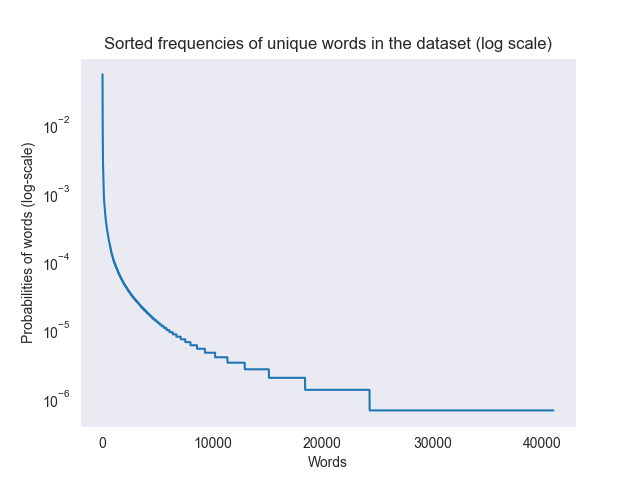

In [10]:
# Make a plot
plt.close("all")
sns.set_style("dark")
sns.lineplot(df_filteredWordDescription["Frequency"]/df_filteredWordDescription["Frequency"].sum())
plt.yscale("log")

plt.title(f"Sorted frequencies of unique words in the dataset (log scale)")
plt.xlabel("Words")
plt.ylabel("Probabilities of words (log-scale)")
plt.show()

In this graph (log-lin scale), we clearly see that the proportion of word occurrence quickly drop after the first ten words and that after a thousand word, the proportions drops below 10E-5. In the end, this plot confirms what we observed with the table above: In most of the case, a word is very rare, appearing less than 10 times for over 75% of the time.

##### **Genres stats**
First how genres are distributed:

[['Romance', 'Fantasy', 'Comedy', 'Action', 'Drama', 'Adventure', 'Slice of life', 'Harem', 'School life', 'Supernatural', 'Yaoi', 'Mature', 'Adult', 'Mystery', 'Josei', 'Tragedy', 'Martial arts', 'Shounen', 'Shoujo', 'Sci-fi', 'Psychological', 'Smut', 'Shounen ai', 'Xuanhuan', 'Historical', 'Seinen', 'Ecchi', 'Horror', 'Xianxia', 'Gender bender', 'Yuri', 'Mecha', 'Shoujo ai', 'Wuxia', 'Sports'], [7523, 6309, 4105, 3743, 3672, 3332, 2210, 2048, 1743, 1731, 1627, 1486, 1277, 1043, 1042, 984, 941, 935, 903, 886, 865, 784, 769, 673, 669, 639, 580, 406, 377, 313, 294, 184, 118, 112, 106]]


C:\Users\arnol\AppData\Local\Temp\ipykernel_13788\3904004382.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


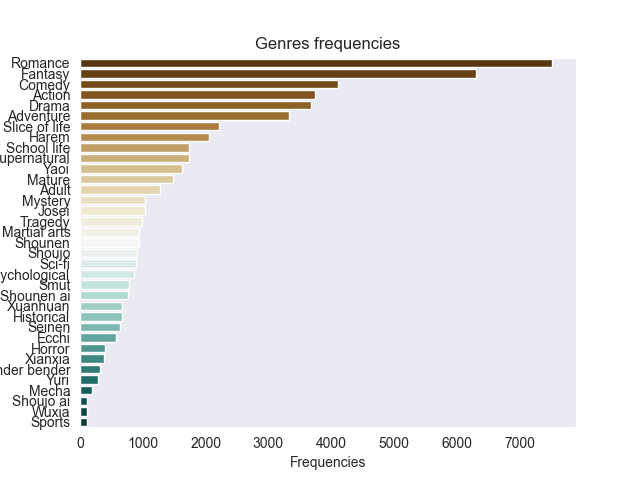

In [11]:
# Get a flatten list of genre
genresList = list(chain.from_iterable(df_filtered.loc[:,"genres"].tolist()))

# Make a counter and sort it
genresCounter = Counter(genresList)
genresCounterSorted = [[],[]]
for genre in sorted(genresCounter, key=lambda x:genresCounter[x], reverse=True):
    genresCounterSorted[0].append(genre)
    genresCounterSorted[1].append(genresCounter[genre])

print(genresCounterSorted)
# Make a plot
plt.close("all")
sns.set_style("dark")
sns.barplot(
    x=genresCounterSorted[1],
    y=genresCounterSorted[0],
    palette="BrBG"    
)
plt.title("Genres frequencies")
plt.xlabel("Frequencies")
plt.ylabel("Genres")

plt.show()

In [12]:
print(genresCounterSorted)

[['Romance', 'Fantasy', 'Comedy', 'Action', 'Drama', 'Adventure', 'Slice of life', 'Harem', 'School life', 'Supernatural', 'Yaoi', 'Mature', 'Adult', 'Mystery', 'Josei', 'Tragedy', 'Martial arts', 'Shounen', 'Shoujo', 'Sci-fi', 'Psychological', 'Smut', 'Shounen ai', 'Xuanhuan', 'Historical', 'Seinen', 'Ecchi', 'Horror', 'Xianxia', 'Gender bender', 'Yuri', 'Mecha', 'Shoujo ai', 'Wuxia', 'Sports'], [7523, 6309, 4105, 3743, 3672, 3332, 2210, 2048, 1743, 1731, 1627, 1486, 1277, 1043, 1042, 984, 941, 935, 903, 886, 865, 784, 769, 673, 669, 639, 580, 406, 377, 313, 294, 184, 118, 112, 106]]


Here we observe that some genres are really underrepresented. It is the case for `Sport`, `Gender Bender`, `Wuxia` and `Mecha`. In consequence, we will simply remove the labels in the dataset to facilitate our prediction.

Additionally, we are in the context where some tags are really close together and could be interchangeable. For example the tags `Shounen AI` and `Yaoi` are defined in the same way, but the focus is on the relationship within the boy-loves for the first and on more tendentious activities for the second (I do not read such things, so I could have made a mistake, but it is what results after some research on Internet). With different semantics, we can also have the same interchangeability remarks with the following genres:

- `Smut` vs `Adult`,
- `Xuanhuan` vs `Xianxia`
- `Yuri` vs `Shoujo AI`
- `Yaoi` vs `Shounen AI`

For the genres concerned, we will simply merge them.

In [13]:
# Dictionary of interchangeable genres
transferGenres = {
    "Smut":"Adult",
    "Shoujo ai":"Yuri",
    "Xianxia":"Xuanhuan",
    "Shounen ai":"Yaoi"
}
# Genres to remove
forbiddenGenres = set([
    "Sports",
    "Wuxia",
    "Mecha",
    "Gender bender"
])

# For each document
dfGenresFiltered = []
for genres in df_filtered.loc[:,"genres"]:
    genres_copy:list = genres.copy()
    
    # Changes the genres by removing/transforming the labels
    for genre in genres:
        if genre in forbiddenGenres:
            genres_copy.remove(genre)
        if genre in transferGenres:
            genres_copy.remove(genre)
            genres_copy.append(transferGenres[genre])
    dfGenresFiltered.append(genres_copy)

df_genresFiltered = df_filtered.copy(deep=True)
df_genresFiltered.loc[:, "genres"] = pd.Series(dfGenresFiltered)

What does it looks like after transformation?

[['Romance', 'Fantasy', 'Comedy', 'Action', 'Drama', 'Adventure', 'Yaoi', 'Slice of life', 'Adult', 'Harem', 'School life', 'Supernatural', 'Mature', 'Xuanhuan', 'Mystery', 'Josei', 'Tragedy', 'Martial arts', 'Shounen', 'Shoujo', 'Sci-fi', 'Psychological', 'Historical', 'Seinen', 'Ecchi', 'Yuri', 'Horror'], [7523, 6309, 4105, 3743, 3672, 3332, 2396, 2210, 2061, 2048, 1743, 1731, 1486, 1050, 1043, 1042, 984, 941, 935, 903, 886, 865, 669, 639, 580, 412, 406]]


C:\Users\arnol\AppData\Local\Temp\ipykernel_13788\3172256800.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


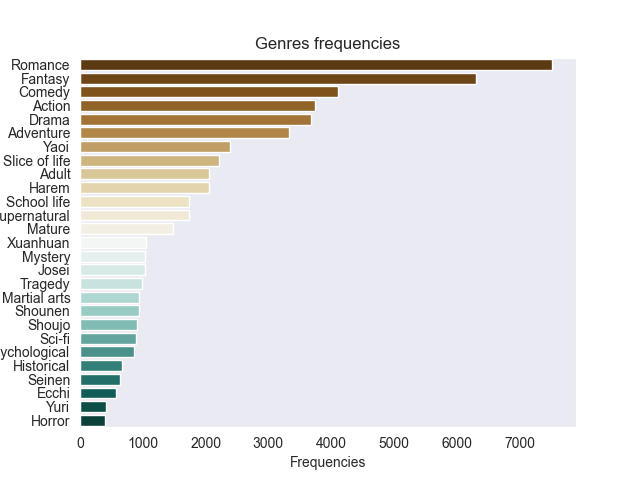

In [14]:
# Get a flatten list of genre
genresList = list(chain.from_iterable(df_genresFiltered.loc[:,"genres"].tolist()))

# Make a counter and sort it
genresCounter = Counter(genresList)
genresCounterSorted = [[],[]]
for genre in sorted(genresCounter, key=lambda x:genresCounter[x], reverse=True):
    genresCounterSorted[0].append(genre)
    genresCounterSorted[1].append(genresCounter[genre])

print(genresCounterSorted)
# Make a plot
plt.close("all")
sns.set_style("dark")
sns.barplot(
    x=genresCounterSorted[1],
    y=genresCounterSorted[0],
    palette="BrBG"    
)
plt.title("Genres frequencies")
plt.xlabel("Frequencies")
plt.ylabel("Genres")

plt.show()

It turned good. Second, how do genres interacts togethers: 

In [15]:
# Create the genre id dictionary
genreToGenreID = {genre:i for i, genre in enumerate(set(genresList))}
genreIDtoGenre = {value:key for key, value in genreToGenreID.items()}
print(genreToGenreID, genreIDtoGenre, sep="\n")

# Create the genreCount dictionary
genreMatrix = np.zeros((len(genreIDtoGenre),len(genreIDtoGenre)), dtype=int)

## For all genres
for genres in df_genresFiltered.loc[:,"genres"].tolist():
    # If it is the only genre, then loop to itself
    if len(genres)==1:
        genreMatrix[genreToGenreID[genres[0]], genreToGenreID[genres[0]]] += 1
        continue
    # Otherwise, add a link to all couple of genre which are different
    for genre1 in genres:
        for genre2 in genres:
            if genre1 != genre2:
                genreMatrix[genreToGenreID[genre1], genreToGenreID[genre2]] += 1
#print(genreMatrix)

{'School life': 0, 'Action': 1, 'Drama': 2, 'Horror': 3, 'Slice of life': 4, 'Supernatural': 5, 'Xuanhuan': 6, 'Romance': 7, 'Seinen': 8, 'Yaoi': 9, 'Harem': 10, 'Adventure': 11, 'Tragedy': 12, 'Historical': 13, 'Josei': 14, 'Ecchi': 15, 'Psychological': 16, 'Shounen': 17, 'Adult': 18, 'Sci-fi': 19, 'Shoujo': 20, 'Yuri': 21, 'Mystery': 22, 'Fantasy': 23, 'Mature': 24, 'Martial arts': 25, 'Comedy': 26}
{0: 'School life', 1: 'Action', 2: 'Drama', 3: 'Horror', 4: 'Slice of life', 5: 'Supernatural', 6: 'Xuanhuan', 7: 'Romance', 8: 'Seinen', 9: 'Yaoi', 10: 'Harem', 11: 'Adventure', 12: 'Tragedy', 13: 'Historical', 14: 'Josei', 15: 'Ecchi', 16: 'Psychological', 17: 'Shounen', 18: 'Adult', 19: 'Sci-fi', 20: 'Shoujo', 21: 'Yuri', 22: 'Mystery', 23: 'Fantasy', 24: 'Mature', 25: 'Martial arts', 26: 'Comedy'}


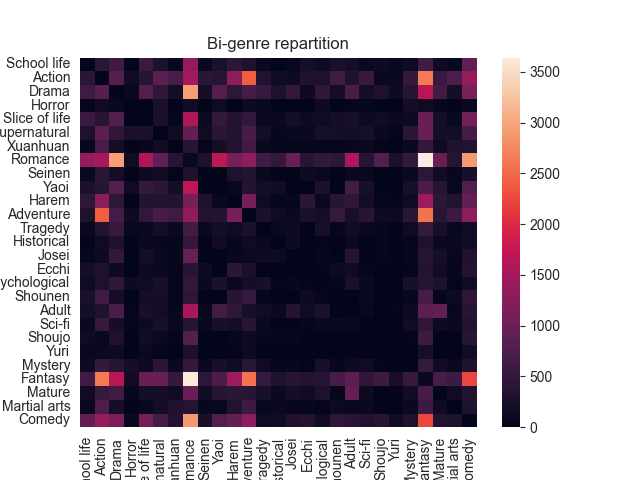

In [16]:
# Make a plot
plt.close("all")
sns.heatmap(genreMatrix,
            xticklabels=list(genreToGenreID.keys()),
            yticklabels=list(genreToGenreID.keys()))
plt.title("Bi-genre repartition")
plt.xlabel("Genre")
plt.ylabel("Genre")

plt.show()

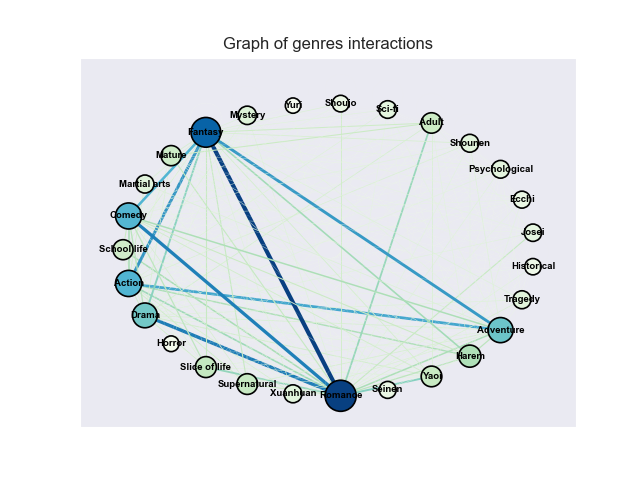

In [17]:
# Make the graph for visibility
G = nx.from_numpy_array(genreMatrix)
G = nx.relabel_nodes(G, dict(enumerate(list(genreToGenreID.keys()))))

# Compute the weights of each edges for the graph
weights = np.array(list(nx.get_edge_attributes(G,"weight").values()))
weights = weights/weights.max()

# Compute the degree of each node to infer nodes sizes
deg = dict(G.degree(weight="weight"))
node_sizes = [100 + 400 * deg[n] / max(deg.values()) for n in G.nodes()]

# Plot the graph
plt.close("all")
nx.draw_networkx(
                 G,                         # The graph 
                 pos=nx.shell_layout(G),    # The layout
                 width=3*weights,           # The width of the edges
                 edge_color=weights,        # Edge colour defined by the weights
                 edge_cmap=plt.cm.GnBu,     # Colour map of the edges
                 font_size="x-small",       # The font size
                 font_color="black",        # The font colour
                 font_weight="bold",        # We want bold
                 font_family="Arial",       # We want Arial
                 node_size=node_sizes,      # The size of the nodes
                 edgecolors="black",        # The border colour of the nodes
                 linewidths=1.2,            # Contour colour of the nodes
                 node_color=node_sizes,     # Colour of the node depends on the degree
                 cmap=plt.cm.GnBu           # Colour map of the nodes
)

# Show the graph
plt.title("Graph of genres interactions")
plt.show()

Here we observe some high correlation between genres which are going to either hinder our work or increase our predictive power depending on our classifications. For example, we have the triad `Adventure`, `Fantasy` and `Action` frequently appearing so if we have the two first, we could have a high chance of having the last.

In the end, the extensive study on the genres, allowed us to remove 8 of the original labels, letting us works from 35 genres to 27 genres. 

## 2.2 - Data Split
In this subpart we discuss data split strategies considering our multilabel situation. Indeed, in our case, doing a classic 60-20-20 split or a stratified split is not necessarily a good choice since multiple labels can appears, thus making balanced division difficult.

A first idea was to make a training-dev-test set for each possible labels, but this would mix the training/test data from one classifier to another while completely avoiding interdependence is impossible in our context.

This is why we will use [**scikit multilearn**](https://web.archive.org/web/20251114024511/https://scikit.ml/stratification.html) `iterative_train_test_split` function as suggested on the [*Data Science Stack Exchange*](https://datascience.stackexchange.com/questions/45174/how-to-use-sklearn-train-test-split-to-stratify-data-for-multi-label-classificat), which provide an optimised version of the classical train test split for multilabel. Note that, in opposition with standard train-test split method, the `iterative` method, described by ***Konstantinos Sechidis et al.*** in the paper [***On the Stratification of Multi-label Data***](link.springer.com/content/pdf/10.1007/978-3-642-23808-6_10.pdf), is usually deterministic and aims to conserve the balance of the different labels in the produced sets. 

Unfortunately, in case of ties, the break is done randomly. From scikit multilearn version 0.2.0, the function implemented in scikit multilearn does not enable us to fix the state. In consequence, we will temporarily fix the state globally using `np.random.seed` (after checking, it seems to work). For simplicity and time constraint, we will evaluate our model on the tie-breaking seed = 0 for training/dev-test split and seed = 42 for dev/test split. Considering the nature of the split method, which is mostly deterministic, this should not have huge consequences.

In our situation, where we have a lot of classes and a decently sized dataset, we will use a 75-15-10 repartition.

In [18]:
# To use the function: https://github.com/scikit-multilearn/scikit-multilearn/discussions/282

# Transform our labels lists into dummy classifier
mlb = MultiLabelBinarizer()
Y = mlb.fit_transform(df_genresFiltered.loc[:,"genres"].tolist())

# Transform our X into something working
X = df_genresFiltered[["description"]].to_numpy()
X = X[..., np.newaxis]

# Register the id of each labels (column of y)
labelIdtoLabelName = {i:label for i, label in enumerate(mlb.classes_)}
labelNameToLabelId = {v:k for k,v in labelIdtoLabelName.items()}


# Train Dev Test Split
## Train Test Split (0.75 training)
## Ensure reproducibility globally
np.random.seed(0)
X_train, y_train, X_test, y_test = iterative_train_test_split(X, Y, test_size = 0.25)
## Test Dev split (0.6*0.25=0.15 dev and 0.4*0.25 = 0.1 test)
np.random.seed(42)
X_test, y_test, X_dev, y_dev = iterative_train_test_split(X_test, y_test, test_size=0.6)

# Reset the seed
np.random.seed(None)

# Print some informations:
print(
f"""
The shape of the training set is {X_train.shape},
the shape of the test set is {X_test.shape},
the shape of the dev set is {X_dev.shape}
"""
)


The shape of the training set is (8765, 1, 1),
the shape of the test set is (1210, 1, 1),
the shape of the dev set is (1795, 1, 1)



# 2.3 - Preprocessing Strategies
In this section, we will justify our preprocessing choices as bullet-points and justification format:
- **Tokenization Method:** Word-level tokenization. We do not plan on using transformers in our multilabel context; indeed, this approach would be too time-consuming without a GPU, this is why we will stick with classical ML techniques such as tf-idf, Bayes, Logistic regressions and pre-trained embeddings like GloVe, which is not trained on subwords. Additionally, in section 2.1bis, we observed many composed word in rare occurrences; in consequence, we will remove the hyphen between the composed word to dilute those into separate tokens. Also, the words are going to be lowercased to uniform the different version of the same word.
- **Lemmatization vs Stemming:** In our case, where we hypothesize that the context of a label was present in the semantics of the tokens and that we can handle higher time complexity (texts are not too long), we chose to use Lemmatization. Indeed, it could yield better results than stemming because its system is context-aware in opposition to Stemming.
- **Stopwords strategy:** In section 2.1bis, we observed that classical stop-words (A, The, To, And, ...) are very frequent without transporting a particular meaning. In this situation, we will use the `nltk` english stopwords set to filter them.
- **Rare word strategy:** In the section 2.1bis, we unravelled that more than half the words are very rare and/or specialised. In this context, we could use tf-idf to detect less important words to filter them based on a proportion or a threshold.
- **Handling of emoji and punctuation:** Since we are not in a sentiment analysis case, emoji (which almost inexistant in our dataset) and punctuation does not unveil a particularly strong semantics. We will therefore remove them. The same will be made for numbers in general.

Now that is being said, we can now preprocess our dataset:

In [19]:
def preprocess(string:str, morphologicalAnalysis:bool = False) -> np.ndarray[str]:
    # Preprocess the string using SpaCy and en_cor_web_sm
    string = nlp(str(string))
    
    # If morphological analysis, stop here
    if morphologicalAnalysis:
        return string
    
    # Get the lemma from the 
    lemmatisedString = " ".join([token.lemma_ for token in string])
    
    # Match all words that are not digits. Match accentuated characters and words with apostrophes (don't, won't ,...)
    strings = re.findall(r"[^\W\d_]+(?:'[^\W\d_]+)*", lemmatisedString)
    
    # Return and remove stop words
    return [word.lower() for word in strings if word.lower() not in stop_words]

# Just so that we know the time spent for preprocessing
begin = time.time()

# Preprocess the test set
preprocessedX_test = [preprocess(X_test[i,0,0]) for i in range(X_test.shape[0])]
print(f"Preprocessing of Test Set done! [{X_test.shape[0]} in {time.time()-begin:.4f}s]")
begin = time.time()

# Preprocess the dev set
preprocessedX_dev = [preprocess(X_dev[i,0,0]) for i in range(X_dev.shape[0])]
print(f"Preprocessing of Dev Set done! [{X_dev.shape[0]} in {time.time()-begin:.4f}s]")
begin = time.time()

# Preprocess the training set
preprocessedX_train = [preprocess(X_train[i,0,0]) for i in range(X_train.shape[0])]
print(f"Preprocessing of Train Set done! [{X_train.shape[0]} in {time.time()-begin:.4f}s]")


Preprocessing of Test Set done! [1210 in 20.2881s]
Preprocessing of Dev Set done! [1795 in 29.6830s]
Preprocessing of Train Set done! [8765 in 139.5302s]


Now that we have successfully preprocessed the text, we should now tokenize it. For that, we will first form the vocabulary on the training set.

In [20]:
# Counter of word from training set
trainingWordCounter = Counter(chain.from_iterable(preprocessedX_train))

# Get a vectorizer
vectorizer = TfidfVectorizer(
    tokenizer = lambda x: x, # Input as tokens
    preprocessor = lambda x: x, # Skip preprocessing (already done)
    token_pattern = None # Disable tokenizer (we already have tokens) 
)

# Get TfIdf
preprocessingTFIDFMatrix = vectorizer.fit_transform(preprocessedX_train)

# Get the vocabulary mapping
trainingVocab = vectorizer.vocabulary_
inversedTrainingVocab = {v:k for k,v in trainingVocab.items()}

# Get the initial size of the training vocabulary
print(f"Size of the vocabulary: {len(trainingVocab)}")

Size of the vocabulary: 26449


From now on, we have the base vocabulary. But it is still too large, even though we passed from 41,025 token in the whole dataset to 26,449 just by removing stopwords, lemmatizing and taking the training set vocabulary only.

To solve this issue, we will impose a threshold on the average tf-idf per tokens. Indeed, tokens of less importance would have tendencies to possess lower tf-idf.

In [21]:
# The minimal threshold on tf-idf for which a token is not considered rare anymore. 
# This threshold is purely arbitrary and could be used as an hyperparameter if the time/Processing time is on our side
# This threshold was chose to observe token that are not atrociously rare while being important in the semantics. By this
# threshold, we have approximately 2.2k vocabulary size, which is also reasonable for our system. 
threshold = 0.0005 #0.0005

# Get the vocab above the threshold in term of average tf-idf
filteredVocabID = np.argwhere(preprocessingTFIDFMatrix.mean(axis=0)>threshold)[:,1]
filterVocab = set([inversedTrainingVocab[i] for i in filteredVocabID])

# Plot the results of the selection
pd.DataFrame(
    list(sorted([(
        vocab, 
        trainingWordCounter[vocab],
        preprocessingTFIDFMatrix[:, trainingVocab[vocab]].mean(axis=0).round(6).tolist()[0][0]
    ) for vocab in filterVocab], key=lambda x: x[2], reverse=True)),
    columns=["Token", "Frequency", "Average tf-idf"]
)



,Token,Frequency,Average tf-idf
0,world,5370,0.026643
1,life,4474,0.021673
2,one,4411,0.019427
3,love,3238,0.018241
4,become,3513,0.016915
...,...,...,...
2184,severe,40,0.000503
2185,enormous,37,0.000502
2186,activity,39,0.000502
2187,virtuous,35,0.000501


Now that we have selected the worthy tokens, we can filter our tokens depending on whether they are out of the vocabulary: `<oov>`.

In [22]:
# Filter <oov> for training set
preprocessedFilteredX_train = [
    list(map(lambda x: "<oov>" if x not in filterVocab else x, doc)) for doc in preprocessedX_train
]

# Filter <oov> for dev set
preprocessedFilteredX_dev = [
    list(map(lambda x: "<oov>" if x not in filterVocab else x, doc)) for doc in preprocessedX_dev
]

# Filter <oov> for test set
preprocessedFilteredX_test = [
    list(map(lambda x: "<oov>" if x not in filterVocab else x, doc)) for doc in preprocessedX_test
]

# Check if it worked
print(preprocessedFilteredX_test[0])

['luo', 'ning', 'cannon', 'fodder', 'female', 'support', 'character', 'entertainment', 'circle', 'love', 'novel', 'reborn', 'refuse', 'cannon', 'fodder', '<oov>', 'fan', '<oov>', 'luo', 'ning', 'flower', '<oov>', '<oov>', 'dance', 'act', 'every', 'day', 'know', 'tie', 'top', 'celebrity', 'gain', '<oov>', 'nothing', 'good', 'look', 'later', 'luo', 'ning', 'appear', 'front', 'public', '<oov>', 'dance', '<oov>', '<oov>', 'four', 'art', 'survive', 'wild', 'cook', 'delicious', 'food', 'draw', '<oov>', 'look', 'beautiful', 'high', 'iq', 'super', '<oov>', 'acting', 'skill', '<oov>', 'fan', 'get', 'good', 'slap', 'face', 'big', 'sister', 'choose', 'suddenly', 'one', 'day', '<oov>', 'search', 'go', '<oov>', '<oov>', 'mysterious', 'king', 'silver', 'screen', 'lu', 'xun', 'kiss', 'luo', 'ning', '<oov>', 'release', '<oov>', 'quickly', 'become', 'top', '<oov>', '<oov>', 'non', 'fan', '<oov>', 'could', 'believe', 'could', '<oov>', 'must', '<oov>', 'luo', 'ning', 'try', 'tie', 'good', 'actor', 'gain'

From this sanity check, we can clearly see that it does work. Now, if we want to proceed to the next steps, we will have to vectorise theses texts. For that, we will again use tf-idf as a vectorisation method.

In [23]:
# Vectorise training set
X_train_tfidfVectorised = vectorizer.fit_transform(preprocessedFilteredX_train)

# Sanity check. Check whether the size of the vocabulary is the same (if we add oov)
N = vectorizer.vocabulary_.keys().__len__()
print(X_train_tfidfVectorised.shape, X_train_tfidfVectorised.shape[1]==N)

# Vectorise dev set and check
X_dev_tfidfVectorised = vectorizer.transform(preprocessedFilteredX_dev)
print(X_dev_tfidfVectorised.shape, X_dev_tfidfVectorised.shape[1]==N)

# Vectorise test and check
X_test_tfidfVectorised = vectorizer.transform(preprocessedFilteredX_test)
print(X_test_tfidfVectorised.shape, X_test_tfidfVectorised.shape[1]==N)

(8765, 2190) True
(1795, 2190) True
(1210, 2190) True


**Vocabulary Size:** In the end, the vocabulary size decreased from 41,025 words to 2,190 words (including `<oov>`), thus leading to a decrease of approximately 95% of the vocabulary size. Concerning the `<oov>` proportion, we can calculate it easily as done underneath.

In [24]:
# Count occurrences in each dataset 
trainCount = Counter(chain.from_iterable(preprocessedFilteredX_train))
devCount = Counter(chain.from_iterable(preprocessedFilteredX_dev))
testCount = Counter(chain.from_iterable(preprocessedFilteredX_test))

# Retrieve OOV proportion.
print(f"Training Set: #<oov>={trainCount['<oov>']}, #token={trainCount.total()}, <oov> proportion: {trainCount['<oov>']/trainCount.total()*100:.4f}%")
print(f"Dev Set: #<oov>={devCount['<oov>']}, #token={devCount.total()}, <oov> proportion: {devCount['<oov>']/devCount.total()*100:.4f}%")
print(f"Test Set: #<oov>={testCount['<oov>']}, #token={testCount.total()}, <oov> proportion: {testCount['<oov>']/testCount.total()*100:.4f}%")


Training Set: #<oov>=110623, #token=574402, <oov> proportion: 19.2588%
Dev Set: #<oov>=22724, #token=116582, <oov> proportion: 19.4919%
Test Set: #<oov>=15074, #token=77449, <oov> proportion: 19.4631%


Here, the `<oov>` proportion is consistent among the tree dataset and reaches about 20%. This seems enormous until we remind that we intentionally classified rare words into `<oov>` to prune the vocabulary. Just for to avoid recomputing all of this, we will now store these sets.

In [25]:
# Save the X sets with tf-idf
with open("pickledFiles/X_train_tfidfVectorised.pkl", "wb") as file:
    pkl.dump(X_train_tfidfVectorised, file)
with open("pickledFiles/X_dev_tfidfVectorised.pkl", "wb") as file:
    pkl.dump(X_dev_tfidfVectorised, file)
with open("pickledFiles/X_test_tfidfVectorised.pkl", "wb") as file:
    pkl.dump(X_test_tfidfVectorised, file)

# Save the y sets
with open("pickledFiles/y_train.pkl", "wb") as file:
    pkl.dump(y_train, file)
with open("pickledFiles/y_dev.pkl", "wb") as file:
    pkl.dump(y_dev, file)
with open("pickledFiles/y_test.pkl", "wb") as file:
    pkl.dump(y_test, file)

# Save the labels
with open("pickledFiles/labelNameToLabelId_labelIdToLabelName.pkl", "wb") as file:
    pkl.dump((labelNameToLabelId, labelIdtoLabelName), file)
with open("pickledFiles/classes_.pkl", "wb") as file:
    pkl.dump(mlb.classes_, file)

From this observation, this seems reasonable. For our second modeling, we will use the [GloVe](https://nlp.stanford.edu/projects/glove/) embedding 2024 Wikipedia + Gigaword 5 (11.9B tokens, 1.2M vocab, uncased, 100d vectors, 560 MB download) available [here](https://nlp.stanford.edu/data/wordvecs/glove.2024.wikigiga.100d.zip) and published in the paper [***A New Pair of GloVes***](https://arxiv.org/abs/2507.18103) by ***Riley Carlson et al.***

The particularity of GloVe is that the embedding is capable of understanding the underlying linear structures between words. For example we would have King-Man+Woman approximately equal to Queen. This structure will be useful to provide a document embedding, which we will exploit for classification.

Note (How to download GloVe): when downloaded, unzip it, and place the obtained file in the folder `GloVe` after renaming it into `GloVe2024.txt` 

In [26]:
# Load GloVe
# Solution adapted from https://stackoverflow.com/questions/37793118/load-pretrained-glove-vectors-in-python
class GloVeClass():
    def __init__(self, path: str):
        self.GloVe = pd.read_table(path, sep=" ", index_col=0, header=None, quoting=csv.QUOTE_NONE)
        self.GloVeMatrix = self.GloVe.to_numpy()
        self.dim = self.GloVe.shape[1]

        # Precompute normalized matrix to make closest word faster
        norms = np.linalg.norm(self.GloVeMatrix, axis=1, keepdims=True)
        self.GloVeMatrixNorm = self.GloVeMatrix / norms

    def closestWord(self, vec: np.ndarray) -> str:
        # Normalise the input vector
        vec_norm = vec / np.linalg.norm(vec)
        
        # Compute cosine similarity as only dot product since it is already normalised (||A||*||B||) 
        cos = np.dot(self.GloVeMatrixNorm, vec_norm)
        
        # Get the index with the highest cosine similarity
        i = np.argmax(cos)
        
        # Get the word
        return self.GloVe.iloc[i].name

    def getVector(self, tokens:list[str]) -> np.ndarray:
        # If the list is empty, return nan for the document embedding
        if len(tokens) == 0:
            return np.full((1, self.dim), np.nan)
        
        # By defaults, embedding is unknown
        result = np.full((len(tokens), self.dim), np.nan)

        # Find which tokens exist
        mask = [t in self.GloVe.index for t in tokens]

        # If tokens exists
        if any(mask):
            # Get the terms
            found_tokens = [t for t, m in zip(tokens, mask) if m]
            
            # Place the vector at the right position
            result[mask] = self.GloVe.loc[found_tokens].to_numpy()

        return result
        
    def getCosineSimilarity(self, vec1:np.ndarray, vec2:np.ndarray) -> float:
        return np.dot(vec1, vec2)/(np.linalg.norm(vec1)*np.linalg.norm(vec2))
        
# Check whether GloVe was well imported
GloVe = GloVeClass(path="GloVe/GloVe2024.txt")

Now that we imported GloVe, we will just perform small sanity checks.
- If I take a Pizza and remove the Italian component and add back a Japanese component, will I get Sushi?
- What happen if I give an empty list of string?
- What happen if an unknown word is given? 

In [27]:
# We indeed get sushis
print(GloVe.closestWord((GloVe.getVector(["pizza"])-GloVe.getVector(["italy"])+GloVe.getVector(["japan"]))[0]))

# We get a full nan vector
print(np.nanmean(GloVe.getVector([]), axis=0))

# The mean of nan give nan
print(np.nanmean(GloVe.getVector(["<oov>", "<oov>"]), axis=0))

# The mean of nan and known words give the mean without nan.
print(np.nanmean(GloVe.getVector(["pizza", "<oov>"]), axis=0))


sushi
[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan]
[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan]
[-0.597682  0.800201 -0.821124 -0.629171 -0.348775 -0.183689  0.491192
 -1.639139 -0.350868  0.745271 -0.168258  0.451539 -0.46893   0.666111
  0.06937  -0.207809  0.600642  0.2536

C:\Users\arnol\AppData\Local\Temp\ipykernel_13788\248797406.py:5: RuntimeWarning: Mean of empty slice
  print(np.nanmean(GloVe.getVector([]), axis=0))
C:\Users\arnol\AppData\Local\Temp\ipykernel_13788\248797406.py:8: RuntimeWarning: Mean of empty slice
  print(np.nanmean(GloVe.getVector(["<oov>", "<oov>"]), axis=0))


Yes, we get sushis. If we get empty lists, it just returns a vector of nan, same for a term if it is unknown.

Now back to something serious. Since the underlying structure can be considered captured, we would like to embed all our document using this embedding instead of tf-idf. We will keep the filtering of words though.

**WARNING: This section is very long to run (>4h). Use the precomputed pickle instead.**

In [28]:
# Get Document embedding for training
print("---Training---")
begin = time.time()
X_train_GloVeVectorised = []

# For each document
for i, trainDocument in enumerate(preprocessedFilteredX_train):
    # Inform the user
    if i%100 == 0:
        print(f"{i}/{len(preprocessedFilteredX_train)} [{time.time()-begin:.5f}s]")

    # Get the average document vector ignoring <oov>.
    X_train_GloVeVectorised.append(np.nanmean(GloVe.getVector(trainDocument), axis=0))
    
# Normalise the resulting vectors
X_train_GloVeVectorised = X_train_GloVeVectorised/np.linalg.norm(X_train_GloVeVectorised, axis=1, keepdims=True)

# Save the results
with open("pickledFiles/X_train_GloVeVectorised.pkl", "wb") as file:
    pkl.dump(X_train_GloVeVectorised, file)

---Training---
0/8765 [0.00000s]
100/8765 [96.94823s]
200/8765 [184.42676s]
300/8765 [277.34614s]
400/8765 [386.27548s]
500/8765 [477.83135s]
600/8765 [571.67267s]


C:\Users\arnol\AppData\Local\Temp\ipykernel_13788\1765558322.py:13: RuntimeWarning: Mean of empty slice
  X_train_GloVeVectorised.append(np.nanmean(GloVe.getVector(trainDocument), axis=0))


700/8765 [674.28080s]
800/8765 [770.80613s]
900/8765 [863.79690s]
1000/8765 [966.13621s]
1100/8765 [1065.04448s]


C:\Users\arnol\AppData\Local\Temp\ipykernel_13788\1765558322.py:13: RuntimeWarning: Mean of empty slice
  X_train_GloVeVectorised.append(np.nanmean(GloVe.getVector(trainDocument), axis=0))


1200/8765 [1152.13608s]


...

2700/8765 [2570.17186s]
2800/8765 [2669.24136s]
2900/8765 [2771.71116s]
3000/8765 [2882.55948s]
3100/8765 [2990.83967s]
3200/8765 [3094.74410s]
3300/8765 [3202.92914s]
3400/8765 [3323.86491s]
3500/8765 [3434.30851s]
3600/8765 [3542.98338s]
3700/8765 [3643.58624s]
3800/8765 [3760.53362s]
3900/8765 [3870.83779s]
4000/8765 [3977.80816s]
4100/8765 [4074.33070s]


C:\Users\arnol\AppData\Local\Temp\ipykernel_13788\1765558322.py:13: RuntimeWarning: Mean of empty slice
  X_train_GloVeVectorised.append(np.nanmean(GloVe.getVector(trainDocument), axis=0))


4200/8765 [4179.68485s]
4300/8765 [4294.78825s]


C:\Users\arnol\AppData\Local\Temp\ipykernel_13788\1765558322.py:13: RuntimeWarning: Mean of empty slice
  X_train_GloVeVectorised.append(np.nanmean(GloVe.getVector(trainDocument), axis=0))


4400/8765 [4395.09550s]
4500/8765 [4494.43897s]
4600/8765 [4592.98468s]
4700/8765 [4696.41068s]
4800/8765 [4809.78884s]
4900/8765 [4924.81356s]
5000/8765 [5019.66863s]
5100/8765 [5114.20873s]
5200/8765 [5205.68249s]
5300/8765 [5295.97628s]
5400/8765 [5385.93071s]
5500/8765 [5485.25794s]
5600/8765 [5579.19663s]
5700/8765 [5675.72229s]
5800/8765 [5775.41233s]
5900/8765 [5866.87053s]
6000/8765 [5961.12779s]
6100/8765 [6052.56761s]
6200/8765 [6139.45962s]
6300/8765 [6230.48258s]
6400/8765 [6317.84074s]
6500/8765 [6402.49967s]
6600/8765 [6496.33801s]
6700/8765 [6588.39576s]
6800/8765 [6681.98671s]
6900/8765 [6782.48097s]
7000/8765 [6875.41965s]
7100/8765 [6973.83235s]
7200/8765 [7087.86742s]
7300/8765 [7185.49120s]
7400/8765 [7288.13103s]
7500/8765 [7405.70189s]
7600/8765 [7500.74098s]
7700/8765 [7620.24057s]
7800/8765 [7727.89965s]
7900/8765 [7828.05839s]
8000/8765 [7936.94191s]
8100/8765 [8045.52420s]
8200/8765 [8147.54292s]
8300/8765 [8244.53102s]
8400/8765 [8348.16729s]
8500/8765 [8459.

In [29]:
# Get Document embedding for dev
print("---Dev---")
begin = time.time()
X_dev_GloVeVectorised = []

# For each document
for i, devDocument in enumerate(preprocessedFilteredX_dev):
    # Inform the user
    if i%100 == 0:
        print(f"{i}/{len(preprocessedFilteredX_dev)} [{time.time()-begin:.5f}s]")

    # Get the average document vector ignoring <oov>.
    X_dev_GloVeVectorised.append(np.nanmean(GloVe.getVector(devDocument), axis=0))
    
# Normalise the resulting vectors
X_dev_GloVeVectorised = X_dev_GloVeVectorised/np.linalg.norm(X_dev_GloVeVectorised, axis=1, keepdims=True)

# Save the results
with open("pickledFiles/X_dev_GloVeVectorised.pkl", "wb") as file:
    pkl.dump(X_dev_GloVeVectorised, file)

---Dev---
0/1795 [0.00000s]
100/1795 [116.00680s]
200/1795 [214.00428s]
300/1795 [306.88523s]
400/1795 [412.24012s]
500/1795 [515.76766s]
600/1795 [616.98793s]
700/1795 [722.78656s]
800/1795 [836.39690s]
900/1795 [935.72032s]
1000/1795 [1044.14062s]
1100/1795 [1146.71399s]
1200/1795 [1257.79577s]
1300/1795 [1360.14620s]
1400/1795 [1475.26936s]
1500/1795 [1583.21149s]
1600/1795 [1693.87401s]
1700/1795 [1785.03065s]


In [30]:
# Get Document embedding for dev
print("---Test---")
begin = time.time()
X_test_GloVeVectorised = []

# For each document
for i, testDocument in enumerate(preprocessedFilteredX_test):
    # Inform the user
    if i%100 == 0:
        print(f"{i}/{len(preprocessedFilteredX_test)} [{time.time()-begin:.5f}s]")

    # Get the average document vector ignoring <oov>.
    X_test_GloVeVectorised.append(np.nanmean(GloVe.getVector(testDocument), axis=0))
    
# Normalise the resulting vectors
X_test_GloVeVectorised = X_test_GloVeVectorised/np.linalg.norm(X_test_GloVeVectorised, axis=1, keepdims=True)

# Save the results
with open("pickledFiles/X_test_GloVeVectorised.pkl", "wb") as file:
    pkl.dump(X_test_GloVeVectorised, file)

---Test---
0/1210 [0.00000s]
100/1210 [104.78642s]
200/1210 [200.12514s]
300/1210 [315.99783s]
400/1210 [418.60039s]
500/1210 [519.60708s]
600/1210 [620.58360s]
700/1210 [720.06758s]
800/1210 [826.18177s]
900/1210 [928.20169s]
1000/1210 [1024.20933s]
1100/1210 [1117.44494s]
1200/1210 [1219.29888s]


### **Pickle restoration point**
This is the restoration point to avoid recomputing all of this

In [43]:
# Load the classes of the multilabel binarizer
with open("pickledFiles/classes_.pkl", "rb") as file:
    classes_:np.ndarray[str] = pkl.load(file)

# Get the label to id dicts
with open("pickledFiles/labelNameToLabelId_labelIdToLabelName.pkl", "rb") as file:
    fileContent = pkl.load(file)
    labelNameToLabelId:dict[str,int] = fileContent[0]
    labelIdtoLabelName:dict[int,str] = fileContent[1]

## Get the tf-idf sets
with open("pickledFiles/X_train_tfidfVectorised.pkl", "rb") as file:
    X_train_tfidfVectorised:np.ndarray[float] = pkl.load(file)
with open("pickledFiles/X_dev_tfidfVectorised.pkl", "rb") as file:
    X_dev_tfidfVectorised:np.ndarray[float] = pkl.load(file)
with open("pickledFiles/X_test_tfidfVectorised.pkl", "rb") as file:
    X_test_tfidfVectorised:np.ndarray[float] = pkl.load(file)

## Get the GloVe sets
with open("pickledFiles/X_train_GloVeVectorised.pkl", "rb") as file:
    X_train_GloVeVectorised:np.ndarray[float] = pkl.load(file)
with open("pickledFiles/X_dev_GloVeVectorised.pkl", "rb") as file:
    X_dev_GloVeVectorised:np.ndarray[float] = pkl.load(file)
with open("pickledFiles/X_test_GloVeVectorised.pkl", "rb") as file:
    X_test_GloVeVectorised:np.ndarray[float] = pkl.load(file)

## Get y sets
with open("pickledFiles/y_train.pkl", "rb") as file:
    y_train:np.ndarray[int] = pkl.load(file)
with open("pickledFiles/y_dev.pkl", "rb") as file:
    y_dev:np.ndarray[int] = pkl.load(file)
with open("pickledFiles/y_test.pkl", "rb") as file:
    y_test:np.ndarray[int] = pkl.load(file)

Now, wether the GloVe embedding worked. For that we will just take a look at one instance and the shape. We will also test the number of nan that we will have to drop in our datasets (nan embedding just means it is either full of `<oov>`, that there is no embedding found or that there is no description.) 

In [44]:
print(X_test_GloVeVectorised.shape)
print(X_test_GloVeVectorised[1,:])
print(f"Number of missing entries (Training): {np.isnan(X_train_GloVeVectorised).sum()/GloVe.dim}")
print(f"Number of missing entries (Dev): {np.isnan(X_dev_GloVeVectorised).sum()/GloVe.dim}")
print(f"Number of missing entries (Test): {np.isnan(X_test_GloVeVectorised).sum()/GloVe.dim}")

(1210, 100)
[ 0.01359042  0.02806792 -0.04619222  0.07259577  0.029259    0.0010169
  0.08722882 -0.0429012   0.07853468  0.07057988 -0.02524143  0.01909653
 -0.02352157 -0.02707391 -0.1282359  -0.01826146 -0.00077738  0.09680885
  0.03705659  0.0228977  -0.21966097 -0.01407445 -0.02342482  0.0204378
 -0.08574691  0.16786683 -0.05745785 -0.08459545  0.00059815 -0.05860269
 -0.03509958  0.03293342  0.1330228  -0.05577178 -0.5627161  -0.06396027
  0.09425551 -0.01386239 -0.04886821 -0.00115146 -0.13405699 -0.10983001
  0.08528798 -0.07696635  0.00617978  0.10077662 -0.01033531  0.02328978
  0.41425138 -0.00079269 -0.0569964  -0.11722021 -0.129288    0.15421793
  0.04008615 -0.12725404  0.04174658 -0.01090204 -0.03550508  0.04877824
  0.11877907 -0.03051125 -0.13815396  0.04302495 -0.08192396  0.13269686
 -0.0052358   0.00874607  0.0919222   0.05606102  0.02338914 -0.02785002
 -0.00497118  0.05402683  0.00946504 -0.03945296 -0.07432896 -0.00452235
 -0.06905409  0.00243031 -0.00455187  0.0

Since the presence of unknown embeddings is quite low, we will just ignore them when designing the classifications models.